In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings 
warnings.filterwarnings('ignore')

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, RocCurveDisplay,
    PrecisionRecallDisplay
)

In [3]:
df = pd.read_csv(r'D:\Machine_learning\Data_sets\creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [15]:
X = df.drop('Class',axis=1)
y = df['Class']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y,stratify= y ,test_size=0.20, random_state=42)

In [17]:
trf3 = ColumnTransformer([
    ('scale',StandardScaler(),slice(0,30))
])

In [18]:
X_train_scaled = trf3.fit_transform(X_train)
X_test_scaled = trf3.fit_transform(X_test)
X_train_scaled.shape
X_test_scaled.shape

(56962, 30)

# Training LightGBM Model without calibrating probabilities and Threshold Tuning 

In [8]:
from lightgbm import LGBMClassifier
model_lgbm_final = LGBMClassifier(n_estimators=500,learning_rate=0.1,num_leaves=50,
                                  max_depth=-1,min_child_samples=10,subsample=0.6,
                                  colsample_bytree=0.8,class_weight="balanced",verbosity = -1)

model_lgbm_final.fit(X_train_scaled, y_train)

LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               min_child_samples=10, n_estimators=500, num_leaves=50,
               subsample=0.6, verbosity=-1)

ROC-AUC  : 0.9749
PR-AUC   : 0.8802
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00     56864
    Positive       0.91      0.83      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

[[56856     8]
 [   17    81]]


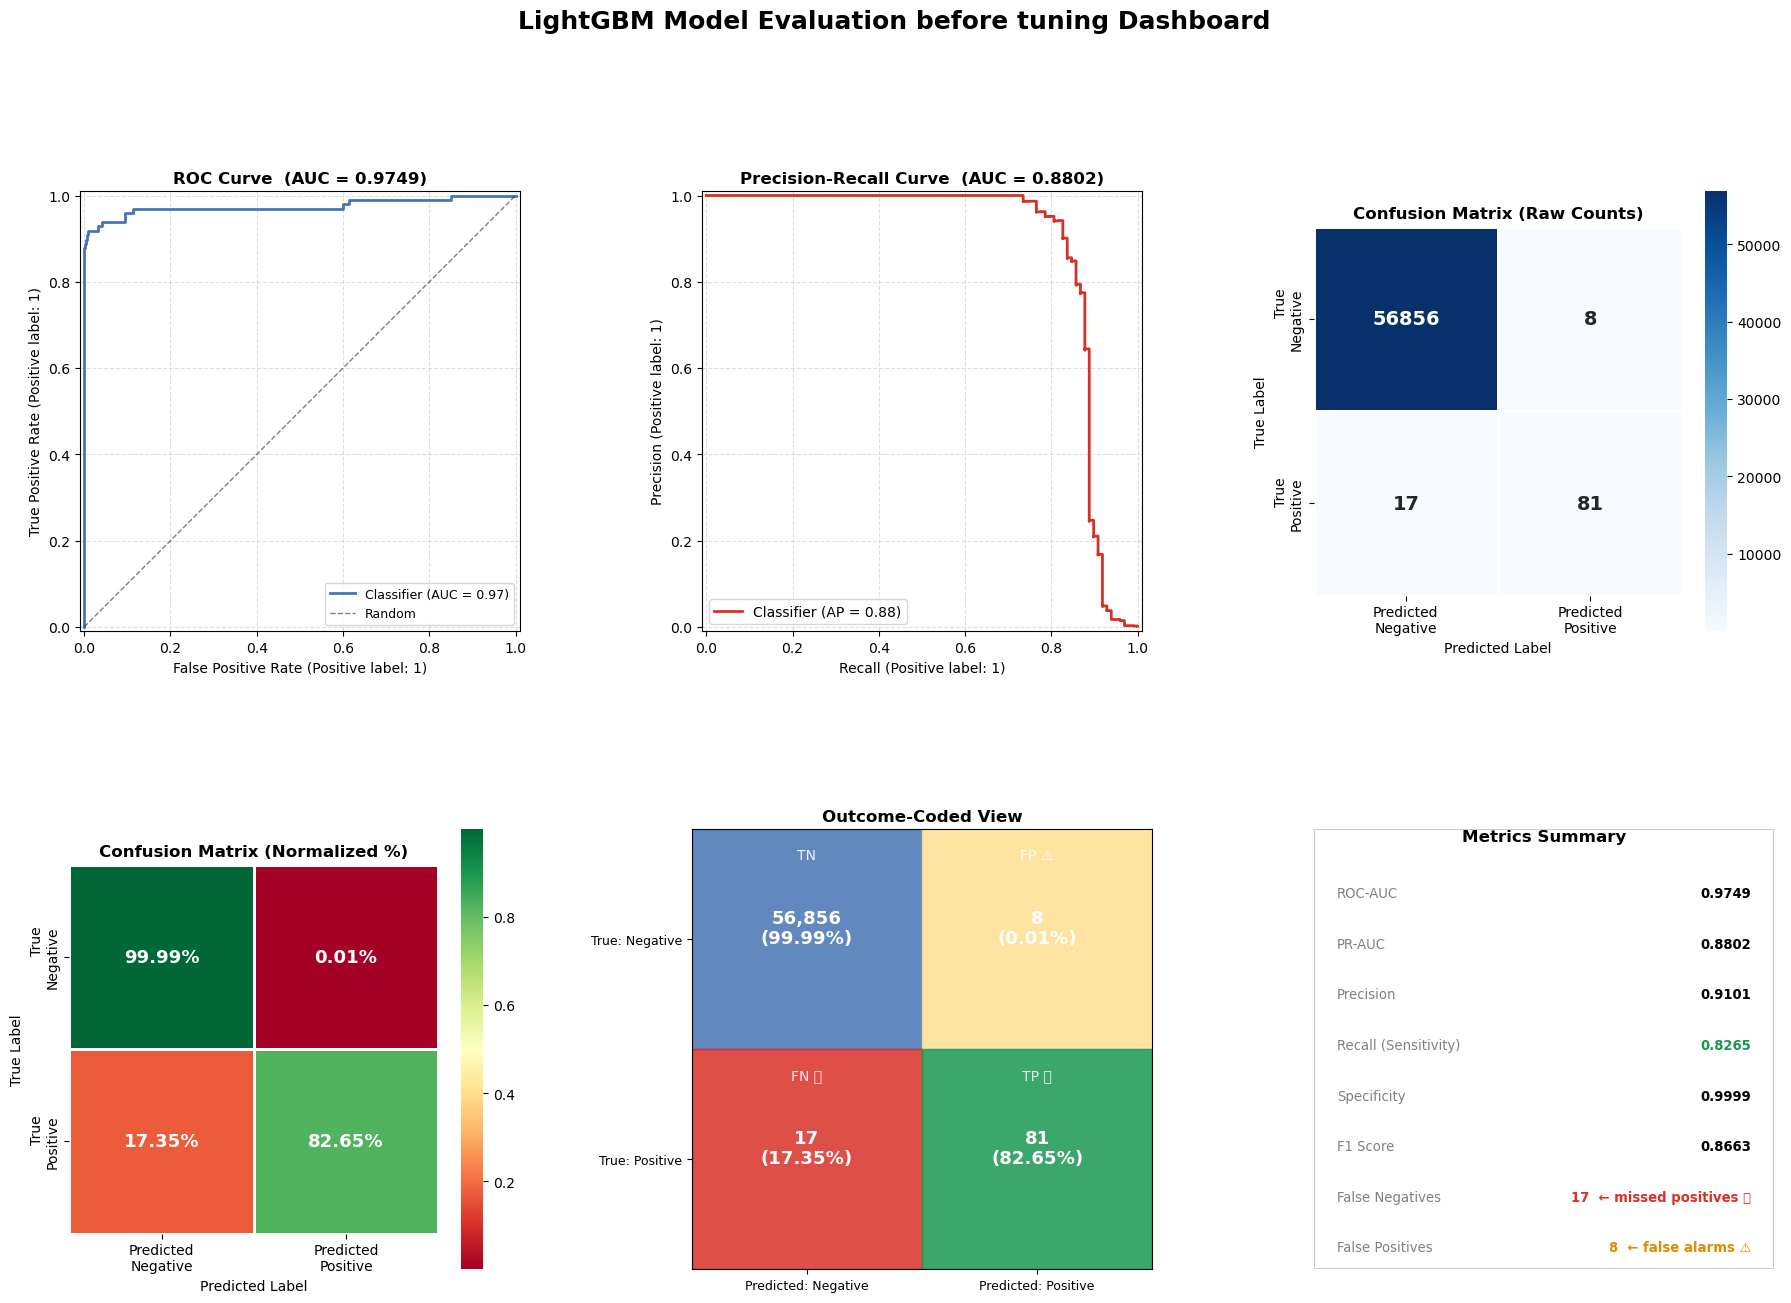

In [14]:


probs = model_lgbm_final.predict_proba(X_test_scaled)[:, 1]
preds = model_lgbm_final.predict(X_test_scaled)

# ── Core Scores ────────────────────────────────────────────────────────────────
roc_auc = roc_auc_score(y_test, probs)
pr_auc  = average_precision_score(y_test, probs)
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")
print(classification_report(y_test, preds, target_names=["Negative", "Positive"]))

# ── Confusion Matrix Data ──────────────────────────────────────────────────────
cm      = confusion_matrix(y_test, preds)
cm_norm = confusion_matrix(y_test, preds, normalize="true")
tn, fp, fn, tp = cm.ravel()
print(cm)

# ══════════════════════════════════════════════════════════════════════════════
# FULL EVALUATION DASHBOARD
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 14))
fig.suptitle("LightGBM Model Evaluation before tuning Dashboard", fontsize=18, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── PLOT 1 — ROC Curve ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
RocCurveDisplay.from_predictions(y_test, probs, ax=ax1, color="#4575b4", linewidth=2)
ax1.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
ax1.set_title(f"ROC Curve  (AUC = {roc_auc:.4f})", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.4)

# ── PLOT 2 — Precision-Recall Curve ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
PrecisionRecallDisplay.from_predictions(y_test, probs, ax=ax2, color="#d73027", linewidth=2)
ax2.set_title(f"Precision-Recall Curve  (AUC = {pr_auc:.4f})", fontsize=12, fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.4)

# ── PLOT 3 — Confusion Matrix: Raw Counts ────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(cm, ax=ax3,
            annot=True, fmt="d",
            cmap="Blues",
            xticklabels=["Predicted\nNegative", "Predicted\nPositive"],
            yticklabels=["True\nNegative",      "True\nPositive"],
            linewidths=2, linecolor="white",
            square=True, cbar=True,
            annot_kws={"size": 14, "weight": "bold"})
ax3.set_title("Confusion Matrix (Raw Counts)", fontsize=12, fontweight="bold")
ax3.set_xlabel("Predicted Label", fontsize=10)
ax3.set_ylabel("True Label",      fontsize=10)

# ── PLOT 4 — Confusion Matrix: Normalized ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm_norm, ax=ax4,
            annot=True, fmt=".2%",
            cmap="RdYlGn",
            xticklabels=["Predicted\nNegative", "Predicted\nPositive"],
            yticklabels=["True\nNegative",      "True\nPositive"],
            linewidths=2, linecolor="white",
            square=True, cbar=True,
            annot_kws={"size": 13, "weight": "bold"})
ax4.set_title("Confusion Matrix (Normalized %)", fontsize=12, fontweight="bold")
ax4.set_xlabel("Predicted Label", fontsize=10)
ax4.set_ylabel("True Label",      fontsize=10)

# ── PLOT 5 — Outcome Color-Coded View ────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
outcome_colors = [["#4575b4", "#fee090"],   # TN=blue,  FP=yellow
                  ["#d73027", "#1a9850"]]    # FN=red,   TP=green
outcome_names  = [["TN", "FP ⚠️"], ["FN 🚨", "TP ✅"]]
for i in range(2):
    for j in range(2):
        ax5.add_patch(plt.Rectangle((j, 1 - i), 1, 1,
                                     color=outcome_colors[i][j], alpha=0.85))
        ax5.text(j + 0.5, 1.55 - i,
                 f"{cm[i, j]:,}\n({cm_norm[i, j]:.2%})",
                 ha="center", va="center",
                 fontsize=13, fontweight="bold", color="white")
        ax5.text(j + 0.5, 1.88 - i, outcome_names[i][j],
                 ha="center", va="center", fontsize=10,
                 color="white", alpha=0.9)
ax5.set_xlim(0, 2); ax5.set_ylim(0, 2)
ax5.set_xticks([0.5, 1.5])
ax5.set_xticklabels(["Predicted: Negative", "Predicted: Positive"], fontsize=9)
ax5.set_yticks([0.5, 1.5])
ax5.set_yticklabels(["True: Positive", "True: Negative"], fontsize=9)
ax5.set_title("Outcome-Coded View", fontsize=12, fontweight="bold")

# ── PLOT 6 — Metrics Summary Card ────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

metrics = [
    ("ROC-AUC",          f"{roc_auc:.4f}",                   "black"),
    ("PR-AUC",           f"{pr_auc:.4f}",                    "black"),
    ("Precision",        f"{precision:.4f}",                 "black"),
    ("Recall (Sensitivity)", f"{recall:.4f}",                "#1a9850"),
    ("Specificity",      f"{specificity:.4f}",               "black"),
    ("F1 Score",         f"{f1:.4f}",                        "black"),
    ("False Negatives",  f"{fn:,}  ← missed positives 🚨",  "#d73027"),
    ("False Positives",  f"{fp:,}  ← false alarms ⚠️",      "#e08a00"),
]
ax6.text(0.5, 1.0, "Metrics Summary", ha="center",
         fontsize=12, fontweight="bold", va="top")
y = 0.87
for name, val, color in metrics:
    ax6.text(0.05, y, name,  fontsize=9.5, va="top", color="gray")
    ax6.text(0.95, y, val,   fontsize=9.5, va="top", ha="right",
             fontweight="bold", color=color)
    y -= 0.115
ax6.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False,
                              edgecolor="#cccccc", linewidth=1.5,
                              transform=ax6.transAxes))

plt.tight_layout()
plt.savefig("lightGBM_evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# Calibrating Probabilities for better Overall Performance

In [19]:
from sklearn.calibration import CalibratedClassifierCV
calibrated_model = CalibratedClassifierCV(model_lgbm_final, method='sigmoid', cv=5)
calibrated_model.fit(X_train_scaled, y_train)


CalibratedClassifierCV(cv=5,
                       estimator=LGBMClassifier(class_weight='balanced',
                                                colsample_bytree=0.8,
                                                min_child_samples=10,
                                                n_estimators=500, num_leaves=50,
                                                subsample=0.6, verbosity=-1))

In [26]:
probs = calibrated_model.predict_proba(X_test_scaled)[:, 1]
preds = calibrated_model.predict(X_test_scaled)
print(classification_report(y_test, preds,
      target_names=['Negative', 'Positive']))

# --- Confusion matrix ---
print(confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00     56864
    Positive       0.91      0.82      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

[[56856     8]
 [   18    80]]


## Getting Threshold Value with calibrated Probabilities

In [28]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Avoid last element (no threshold for it)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Precision: {precision[best_idx]:.3f}  Recall: {recall[best_idx]:.3f}")

Best threshold: 0.374
Precision: 0.911  Recall: 0.837


In [29]:
custom_preds = (probs >= best_threshold).astype(int)
print(classification_report(y_test, custom_preds))
print(confusion_matrix(y_test, custom_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.84      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962

[[56856     8]
 [   16    82]]


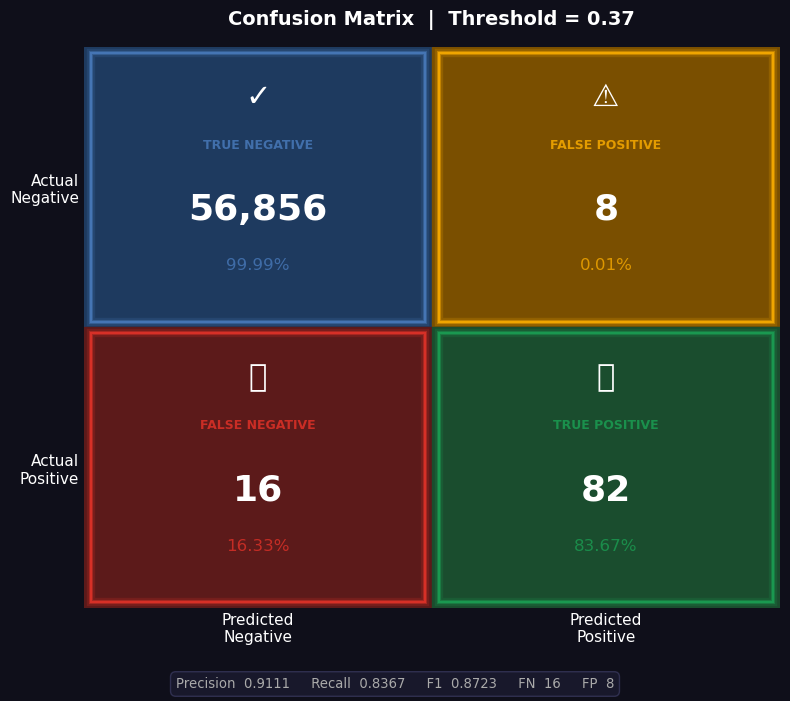

In [34]:
custom_preds = (probs >= best_threshold).astype(int)

cm      = confusion_matrix(y_test, custom_preds)
cm_norm = confusion_matrix(y_test, custom_preds, normalize="true")
tn, fp, fn, tp = cm.ravel()

precision_v = tp / (tp + fp) if (tp + fp) else 0
recall_v    = tp / (tp + fn) if (tp + fn) else 0
f1          = 2 * precision_v * recall_v / (precision_v + recall_v) if (precision_v + recall_v) else 0

# ── Dark theme ────────────────────────────────────────────────────────────────
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor("#0f0f1a")
ax.set_facecolor("#0f0f1a")

outcome_colors = [["#1e3a5f", "#7a4f00"],   # TN=dark blue,  FP=dark amber
                  ["#5c1a1a", "#1a4d2e"]]    # FN=dark red,   TP=dark green
outcome_border = [["#4575b4", "#f0a500"],    # TN border,     FP border
                  ["#d73027", "#1a9850"]]    # FN border,     TP border
outcome_names  = [["TRUE NEGATIVE", "FALSE POSITIVE"],
                  ["FALSE NEGATIVE", "TRUE POSITIVE"]]
outcome_icons  = [["✓", "⚠️"], ["🚨", "✅"]]

for i in range(2):
    for j in range(2):
        # Cell background
        ax.add_patch(plt.Rectangle(
            (j, 1 - i), 1, 1,
            color=outcome_colors[i][j],
            zorder=1
        ))
        # Glowing border
        for lw, alpha in [(6, 0.2), (3, 0.5), (1.5, 1.0)]:
            ax.add_patch(plt.Rectangle(
                (j + 0.02, 1 - i + 0.02), 0.96, 0.96,
                fill=False,
                edgecolor=outcome_border[i][j],
                linewidth=lw, alpha=alpha,
                zorder=2
            ))
        # Icon
        ax.text(j + 0.5, 1.82 - i, outcome_icons[i][j],
                ha="center", va="center", fontsize=22, zorder=3)
        # Label
        ax.text(j + 0.5, 1.65 - i, outcome_names[i][j],
                ha="center", va="center", fontsize=9,
                color=outcome_border[i][j],
                fontweight="bold", alpha=0.9,
                zorder=3)
        # Count
        ax.text(j + 0.5, 1.42 - i, f"{cm[i, j]:,}",
                ha="center", va="center", fontsize=26,
                fontweight="bold", color="white", zorder=3)
        # Percentage
        ax.text(j + 0.5, 1.22 - i, f"{cm_norm[i, j]:.2%}",
                ha="center", va="center", fontsize=12,
                color=outcome_border[i][j], alpha=0.85, zorder=3)

# ── Axis labels ───────────────────────────────────────────────────────────────
ax.set_xlim(0, 2); ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Predicted\nNegative", "Predicted\nPositive"],
                    fontsize=11, color="white")
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["Actual\nPositive", "Actual\nNegative"],
                    fontsize=11, color="white")
ax.tick_params(colors="white", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# ── Title ─────────────────────────────────────────────────────────────────────
ax.set_title(f"Confusion Matrix  |  Threshold = {best_threshold:.2f}",
             fontsize=14, fontweight="bold", color="white", pad=16)

# ── Bottom metrics strip ──────────────────────────────────────────────────────
metrics_text = (f"Precision  {precision_v:.4f}     "
                f"Recall  {recall_v:.4f}     "
                f"F1  {f1:.4f}     "
                f"FN  {fn:,}     FP  {fp:,}")
fig.text(0.5, 0.01, metrics_text,
         ha="center", fontsize=9.5, color="#aaaaaa",
         bbox=dict(boxstyle="round,pad=0.4",
                   facecolor="#1a1a2e", edgecolor="#333355",
                   alpha=0.9))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("LightGBM_tunned_confusion_matrix.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f1a")
plt.show()

# reset style so other plots aren't affected
plt.style.use("default")



# Making A pipeline

In [35]:
from sklearn.pipeline import Pipeline

base_pipeline = Pipeline([
    ('transform', trf3),
    ('model', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.1,
        num_leaves=50,
        max_depth=-1,
        min_child_samples=10,
        subsample=0.6,
        colsample_bytree=0.8,
        class_weight="balanced",
        verbosity=-1  # 👈 hides warnings
)
    )
])

# Step 3: Calibration on FULL pipeline
final_pipeline = CalibratedClassifierCV(
    base_pipeline,
    method='sigmoid',
    cv=5
)

# Step 4: Train everything together
final_pipeline.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('transform',
                                                  ColumnTransformer(transformers=[('scale',
                                                                                   StandardScaler(),
                                                                                   slice(0, 30, None))])),
                                                 ('model',
                                                  LGBMClassifier(class_weight='balanced',
                                                                 colsample_bytree=0.8,
                                                                 min_child_samples=10,
                                                                 n_estimators=500,
                                                                 num_leaves=50,
                                                                 subsample=0.6,
                                                                 verbosity=-1))]))

In [36]:
class FraudModel:
    def __init__(self, model, threshold):
        self.model = model
        self.threshold = threshold

    def predict_proba(self, X):
        X = np.array(X)
        return self.model.predict_proba(X)[:, 1]

    def predict(self, X):
        probs = self.predict_proba(X)
        return (probs >= self.threshold).astype(int)

    def predict_with_scores(self, X):
        probs = self.predict_proba(X)
        preds = (probs >= self.threshold).astype(int)
        return {
            "probabilities": probs.tolist(),
            "predictions": preds.tolist()
        }

    # ✅ ADD THIS
    def get_threshold(self):
        return float(self.threshold)


fraud_model = FraudModel(final_pipeline, threshold=0.374)

# Deployement Phase:  exporting into PKL file

In [37]:
import joblib
joblib.dump(fraud_model, "fraud_model.pkl")

['fraud_model.pkl']

In [38]:
model = joblib.load("fraud_model.pkl")
print(model.threshold)

0.374
